In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
from scipy import stats
import seaborn as sns

In [2]:
def load_volreg(path, mean_radius=9):
    """
    Load motion parameters estimated from AFNI's 3dvolreg and convert radian
    values to distance based on the given mean radius.
    :param path:        Filepath of the 1D motion parameter data.
    :param mean_radius: Distance from the aural canal to the central fissure
                        of the animal (default: 9mm for rat).
    :return:            Motion parameters with rotation values converted to distance.
    """
    def convert_radian_to_distance(volreg, mean_radius):
        """ Convert rotational parameters (in degrees) to displacement (in mm) using mean radius. """
        volreg[['Roll', 'Pitch', 'Yaw']] *= (np.pi / 180 * mean_radius)
        return volreg
    # Load motion parameter data
    volreg = pd.read_csv(path, header=None, sep=r'\s+')
    volreg.columns = ['Roll', 'Pitch', 'Yaw', 'dI-S', 'dR-L', 'dA-P']
    # Adjust radius by a factor of sqrt(2)
    adjusted_radius = np.round(np.sqrt(2) * mean_radius)
    # Convert radian values to distance
    return convert_radian_to_distance(volreg, adjusted_radius)

In [3]:
motion = glob.glob('../../dataset/rat/motion/*.1D')

In [4]:
mean_radius = 9
adjusted_radius = np.round(np.sqrt(2) * mean_radius)
motion_all = pd.DataFrame()
for m in motion:
    sub = os.path.basename(m).split('_')[0]
    run = int(os.path.basename(m).split('_')[2].replace('run-', ''))
    motion_params = np.loadtxt(m)
    rotations_mm = motion_params[:, :3] * (np.pi / 180 * adjusted_radius)
    translations = motion_params[:, 3:]
    motion_mm = np.hstack((rotations_mm, translations))
    fd = np.sum(np.abs(np.diff(motion_mm, axis=0)), axis=1)
    mean_fd = np.mean(fd)
    motion_all = pd.concat([motion_all, pd.DataFrame([sub, run, mean_fd])], axis=1)

In [5]:
motion_all = motion_all.T
motion_all.columns = ['sub', 'run', 'motion']

In [7]:
atlas = pd.read_csv('../../dataset/rat/rat_brainregions.csv')
regions = pd.read_csv('../../dataset/rat/rat_brainatlas.csv', header=None)

In [8]:
df = pd.read_csv('../../derivatives/rat/Hurst_rat_alcohol.csv')

In [9]:
df['avg'] = df.iloc[:, :50].mean(axis=1)
df['H_combined53'] = [int(x.replace('run-', '')) for x in df['H_combined53']]

In [10]:
all_regions = []
for i in np.arange(50):
    all_regions += list(atlas.iloc[i, 1:].values)
regions = list(set(all_regions))[1:]

In [11]:
df_region = pd.DataFrame()
for region in regions:
    region_id = []
    for i in np.arange(50):
        if region in list(atlas.iloc[i, 1:].values):
            region_id.append(i)
    df_region = pd.concat([df_region, df.iloc[:, region_id].mean(axis=1)], axis=1)

In [12]:
df_region.columns = regions

In [13]:
df_region['sub'] = df['H_combined51']
df_region['run'] = df['H_combined53']
df_region_all = df_region

In [14]:
adolescent = [i for i in np.arange(df_region_all.shape[0]) if 'AA' in df_region_all['sub'][i]]
adult = [i for i in np.arange(df_region_all.shape[0]) if 'AB' in df_region_all['sub'][i]]

In [15]:
df_region_all['sex'] = [x[-1] for x in df_region_all['sub']]
df_region_all['age'] = [x[-3:-1] for x in df_region_all['sub']]

In [21]:
runs = []
for i in np.arange(df_region_all.shape[0]):
    if df_region_all.run[i]==1:
        runs.append(1)
    else:
        runs.append(df_region_all.run[i])
df_region_all['run'] = runs

In [22]:
df_region_all = pd.merge(df_region_all, motion_all, on=['sub', 'run'])

In [23]:
df['sub'] = df['H_combined51']
df['run'] = df['H_combined53']
df['sex'] = [x[-1] for x in df_region_all['sub']]
df['age'] = [x[-3:-1] for x in df_region_all['sub']]

In [24]:
df = pd.merge(df, motion_all, on=['sub', 'run'])

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Run: 1, Correlation: 0.07546721535911827, P-value: 0.6665622826448768


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Run: 2, Correlation: -0.3082393251972126, P-value: 0.07162542999819352


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Run: 3, Correlation: -0.06444837977243219, P-value: 0.7130093888067347


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Run: 4, Correlation: -0.29650842441264463, P-value: 0.08370237520388518
Run: 5, Correlation: -0.11164367971303257, P-value: 0.5231439771635729


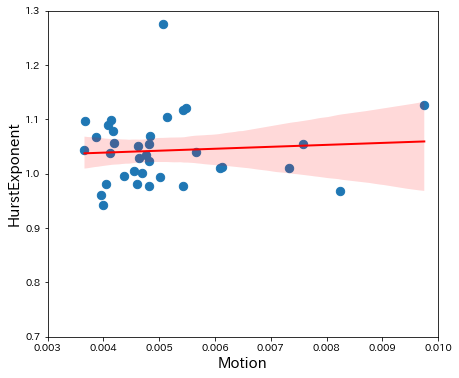

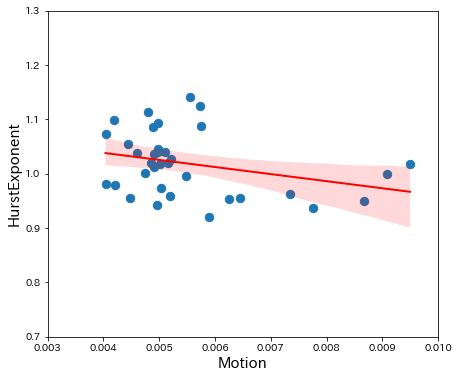

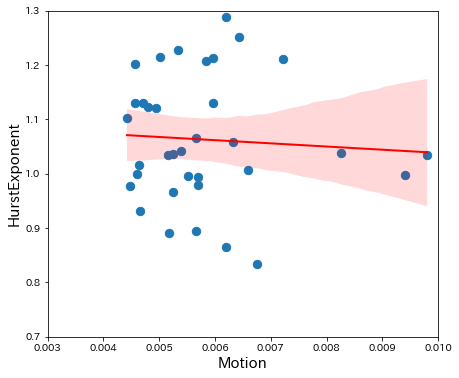

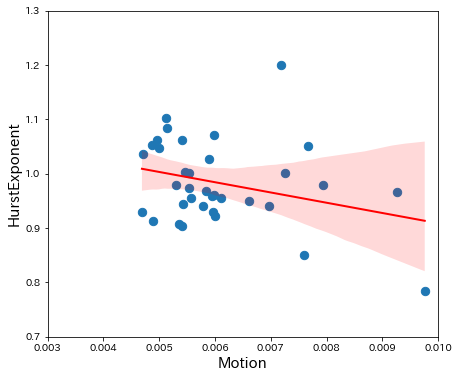

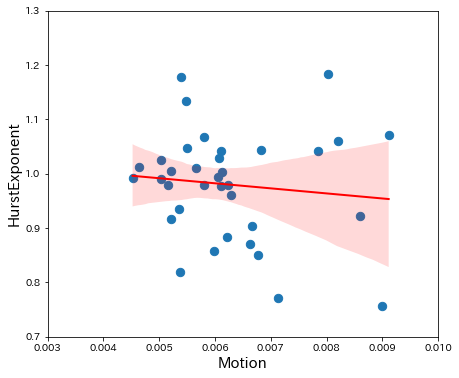

In [27]:
#Fig S2B
df_region_all = df_region_all[df_region_all.motion<0.01]
for run in df_region_all.run.unique():
    figure = plt.figure(figsize=(7,6))
    df_region = df_region_all[df_region_all.run==run]
    plt.scatter(df_region.motion, df_region.iloc[:, :-8].mean(axis=1), s=70)
    plt.xlabel('Motion', size=15)
    plt.ylabel('HurstExponent', size=15)
    plt.ylim([0.7, 1.3])
    plt.xlim([0.003, 0.01])
    motion = df_region.motion.values
    hurst_exponent = df_region.iloc[:, :-8].mean(axis=1).values
    corr, p_val = stats.pearsonr(motion, hurst_exponent)
    sns.regplot(x=motion, y=hurst_exponent, scatter=False, color='red', line_kws={'lw': 2})
    plt.savefig(str(run)+'.eps')
    print(f'Run: {run}, Correlation: {corr}, P-value: {p_val}')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


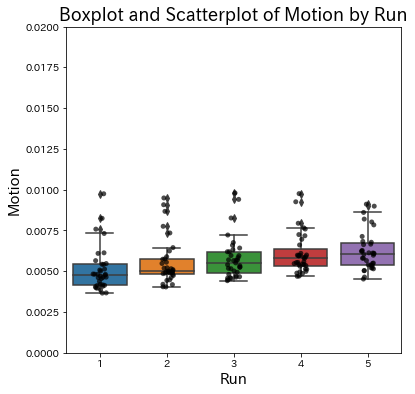

F-statistic: 4.5758, P-value: 0.0016


In [26]:
#Fig S2A
plt.figure(figsize=(6, 6))
# Plot the boxplot
df_region_all['motion'] = [float(x) for x in df_region_all.motion]
sns.boxplot(x='run', y='motion', data=df_region_all)
# Overlay the scatterplot (stripplot) on the boxplot
sns.stripplot(x='run', y='motion', data=df_region_all, color='black', jitter=True, alpha=0.7)
# Set labels and title
plt.xlabel('Run', size=15)
plt.ylabel('Motion', size=15)
plt.title('Boxplot and Scatterplot of Motion by Run', size=18)
# Set y-axis limits
plt.ylim([0, 0.02])
# Save the figure
plt.savefig('motioncomparison.eps', format='eps')
# Display the plot
plt.show()
grouped_data = [group['motion'].values for name, group in df_region_all.groupby('run')]
f_stat, p_value = stats.f_oneway(*grouped_data)
print(f"F-statistic: {f_stat:.4f}, P-value: {p_value:.4f}")